In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("global_climate_change_extreme_weather_2026.csv")
print("--- First 5 Rows of the Dataset ---")
display(df.head())
print("\n--- Dataset Information & Shape ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
print(df.info())

--- First 5 Rows of the Dataset ---


,record_id,country,region,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,flood_risk,drought_risk,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
0,CLM0001,Canada,North America,16.8,2.40,5477,1.44,Low,High,9,25,-117,127,89,92.7,2026
1,CLM0002,Brazil,South America,28.8,1.51,3758,1.55,Medium,Medium,38,197,73,103,81,95.4,2026
2,CLM0003,Australia,Oceania,6.6,1.70,1904,5.81,Medium,Medium,20,161,127,253,71,32.0,2026
3,CLM0004,Germany,Europe,10.9,1.53,3786,5.41,Medium,Low,56,191,-57,166,57,131.5,2026
4,CLM0005,United States,North America,13.9,2.07,732,3.20,High,High,42,76,-22,142,81,93.4,2026



--- Dataset Information & Shape ---
Total Rows: 5000, Total Columns: 16
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   record_id              5000 non-null   str    
 1   country                5000 non-null   str    
 2   region                 5000 non-null   str    
 3   avg_temperature_c      5000 non-null   float64
 4   temperature_change_c   5000 non-null   float64
 5   co2_emissions_mt       5000 non-null   int64  
 6   sea_level_rise_mm      5000 non-null   float64
 7   flood_risk             5000 non-null   str    
 8   drought_risk           5000 non-null   str    
 9   heatwave_days          5000 non-null   int64  
 10  wildfire_incidents     5000 non-null   int64  
 11  rainfall_change_mm     5000 non-null   int64  
 12  air_quality_index      5000 non-null   int64  
 13  climate_risk_score     5000 non-null   int64  

In [2]:
# data cleaning and missing values verification
df.columns = df.columns.str.strip()
print("--- Missing Values Count per Column ---")
print(df.isnull().sum())
duplicate_count = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicate_count}")
print("\n--- Statistical Summary of Numerical Data ---")
display(df.describe())

--- Missing Values Count per Column ---
record_id                0
country                  0
region                   0
avg_temperature_c        0
temperature_change_c     0
co2_emissions_mt         0
sea_level_rise_mm        0
flood_risk               0
drought_risk             0
heatwave_days            0
wildfire_incidents       0
rainfall_change_mm       0
air_quality_index        0
climate_risk_score       0
population_affected_m    0
year                     0
dtype: int64

Total Duplicate Rows: 0

--- Statistical Summary of Numerical Data ---


,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.0
mean,17.491040,1.493576,3145.744600,3.49663,32.407400,148.337800,0.881200,175.280200,57.60100,150.177160,2026.0
std,7.203599,0.576416,1640.113354,1.42864,16.263343,87.615102,86.708135,72.615251,22.02999,86.287074,0.0
min,5.000000,0.500000,301.000000,1.00000,5.000000,0.000000,-150.000000,50.000000,20.00000,1.100000,2026.0
25%,11.300000,0.990000,1708.750000,2.26000,18.000000,70.000000,-73.000000,112.000000,39.00000,78.200000,2026.0
50%,17.400000,1.480000,3173.000000,3.52000,32.000000,149.000000,2.000000,175.000000,58.00000,149.750000,2026.0
75%,23.800000,1.990000,4552.500000,4.74000,47.000000,223.000000,76.000000,239.000000,77.00000,225.025000,2026.0
max,30.000000,2.500000,5999.000000,6.00000,60.000000,300.000000,150.000000,300.000000,95.00000,300.000000,2026.0


--- Average Climate Risk Score by Region ---
region
Asia             58.235375
North America    57.984970
Africa           57.911523
Oceania          57.908367
Europe           56.901057
South America    55.905769
Name: climate_risk_score, dtype: float64




C:\Users\2025\AppData\Local\Temp\ipykernel_16828\1231801513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_risk.index, y=region_risk.values, palette='Spectral')


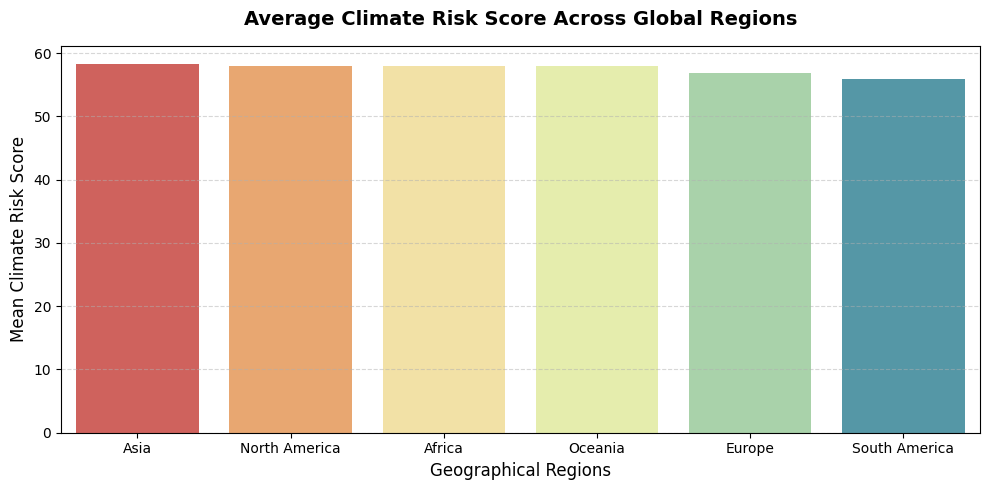

In [5]:
# What is the average climate risk score across different geographical regions? Which region is at the highest risk?
region_risk = df.groupby('region')['climate_risk_score'].mean().sort_values(ascending=False)
print("--- Average Climate Risk Score by Region ---")
print(region_risk)
print("\n" + "="*50 + "\n")
plt.figure(figsize=(10, 5))
sns.barplot(x=region_risk.index, y=region_risk.values, palette='Spectral')
plt.title("Average Climate Risk Score Across Global Regions", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Geographical Regions", fontsize=12)
plt.ylabel("Mean Climate Risk Score", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

--- Top 10 CO2 Emitting Countries (Total MT) ---
country
Germany           1683782
Brazil            1650847
United States     1611988
Pakistan          1592603
United Kingdom    1569860
Australia         1568872
Canada            1548241
China             1523556
India             1496343
Nigeria           1482631
Name: co2_emissions_mt, dtype: int64




C:\Users\2025\AppData\Local\Temp\ipykernel_16828\2429776573.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_co2_countries.index, y=top_co2_countries.values, palette='Reds_r')


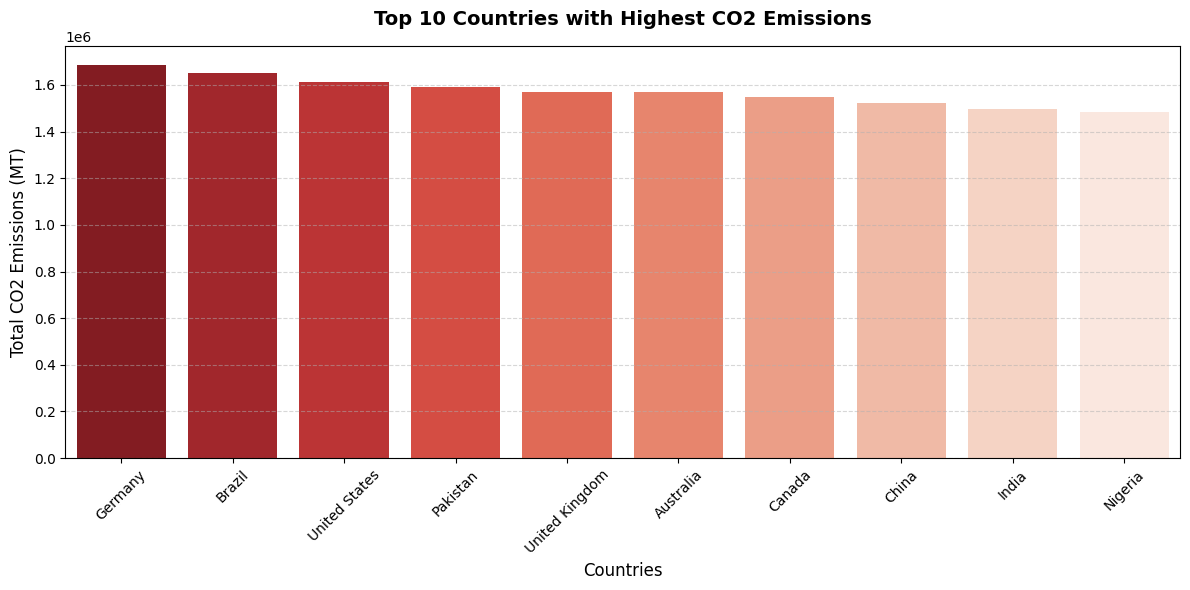

In [6]:
# Which top 10 countries are responsible for the highest $CO_2$ emissions in this dataset?
top_co2_countries = df.groupby('country')['co2_emissions_mt'].sum().sort_values(ascending=False).head(10)
print("--- Top 10 CO2 Emitting Countries (Total MT) ---")
print(top_co2_countries)
print("\n" + "="*50 + "\n")
plt.figure(figsize=(12, 6))
sns.barplot(x=top_co2_countries.index, y=top_co2_countries.values, palette='Reds_r')
plt.title("Top 10 Countries with Highest CO2 Emissions", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Countries", fontsize=12)
plt.ylabel("Total CO2 Emissions (MT)", fontsize=12)
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

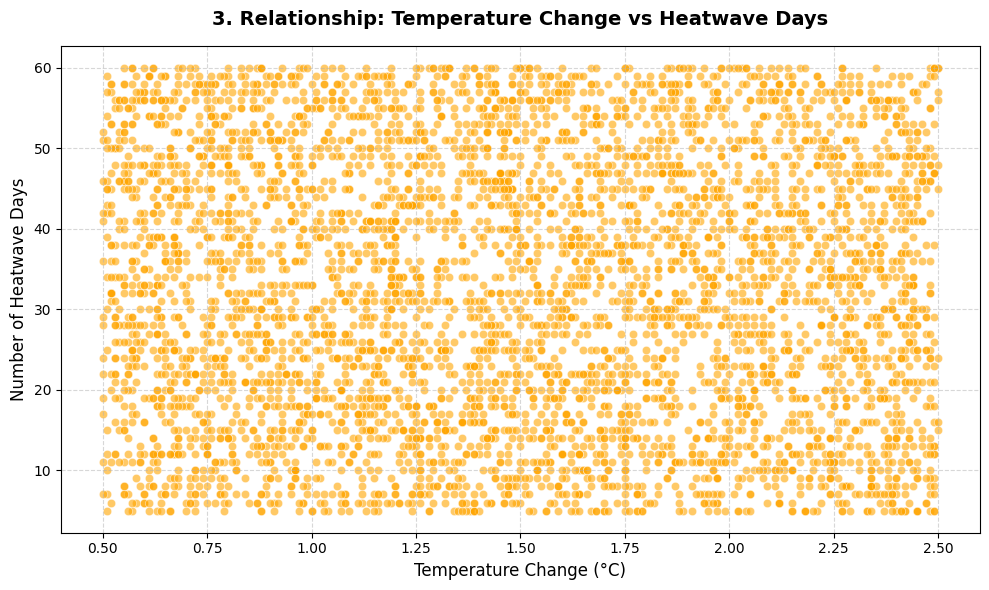

In [7]:
# Is there a positive correlation between temperature change(in celsius) and the number of heatwave days?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temperature_change_c', y='heatwave_days', alpha=0.6, color='orange')
plt.title("3. Relationship: Temperature Change vs Heatwave Days", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Temperature Change (°C)", fontsize=12)
plt.ylabel("Number of Heatwave Days", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\2025\AppData\Local\Temp\ipykernel_16828\3991630958.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='drought_risk', y='wildfire_incidents', order=['Low', 'Medium', 'High'], palette='YlOrBr')


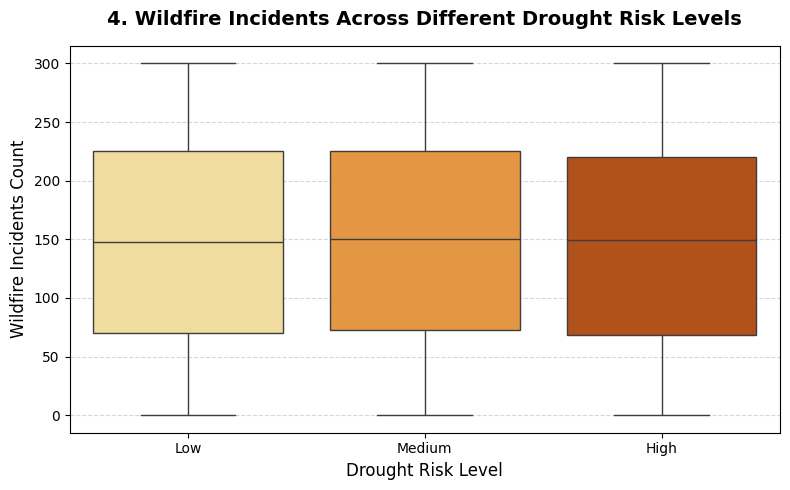

In [8]:
# How do wildfire incidents vary across different levels of drought risk (Low, Medium, High)?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='drought_risk', y='wildfire_incidents', order=['Low', 'Medium', 'High'], palette='YlOrBr')
plt.title("4. Wildfire Incidents Across Different Drought Risk Levels", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Drought Risk Level", fontsize=12)
plt.ylabel("Wildfire Incidents Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\2025\AppData\Local\Temp\ipykernel_16828\3642010431.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='air_quality_index', palette='Set3')


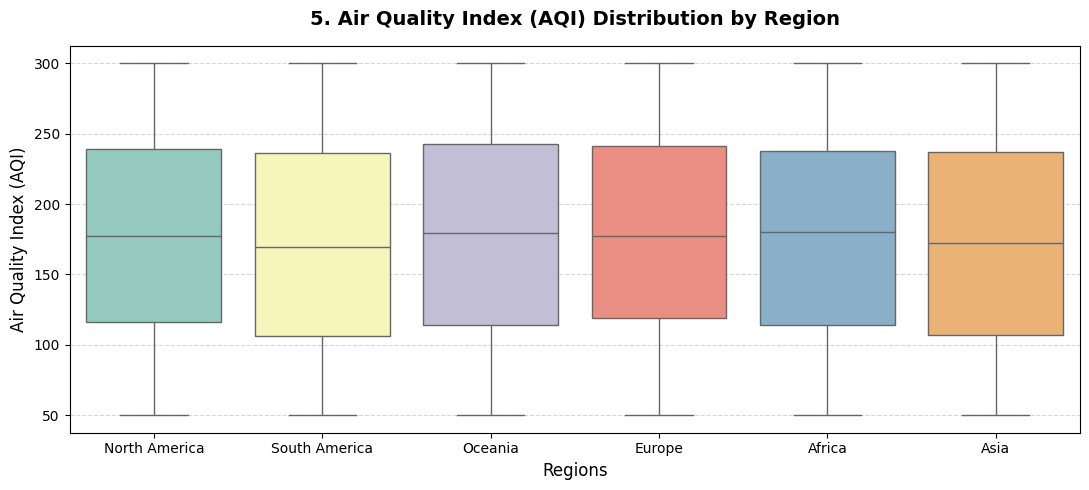

In [9]:
# What is the overall distribution of the Air Quality Index (AQI) across different continental regions?
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='region', y='air_quality_index', palette='Set3')
plt.title("5. Air Quality Index (AQI) Distribution by Region", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Regions", fontsize=12)
plt.ylabel("Air Quality Index (AQI)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

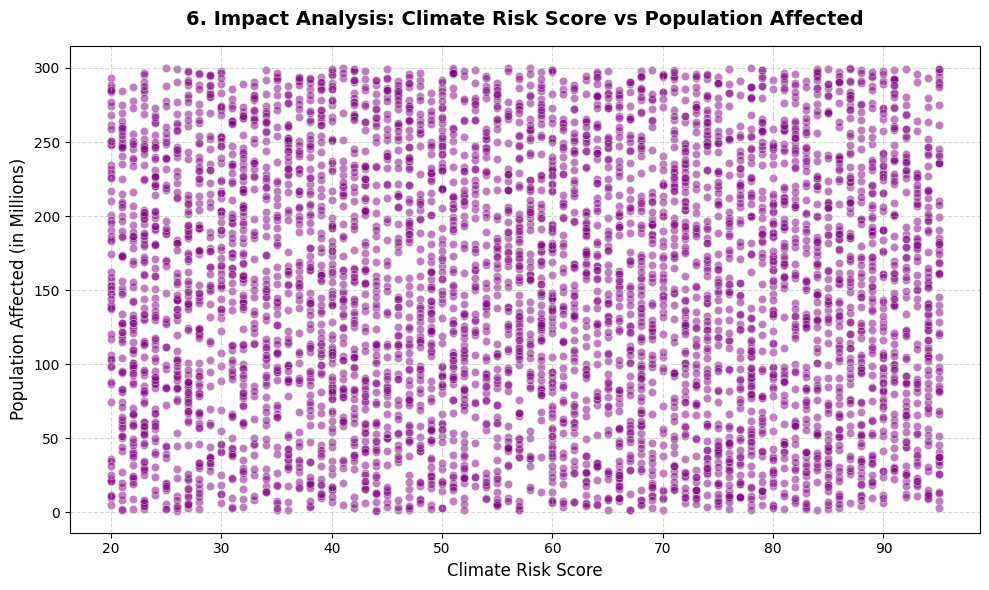

In [24]:
# Does a higher climate risk score directly correlate with a larger population being affected (in millions)?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='climate_risk_score', y='population_affected_m', alpha=0.5, color='purple')
plt.title("6. Impact Analysis: Climate Risk Score vs Population Affected", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Climate Risk Score", fontsize=12)
plt.ylabel("Population Affected (in Millions)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

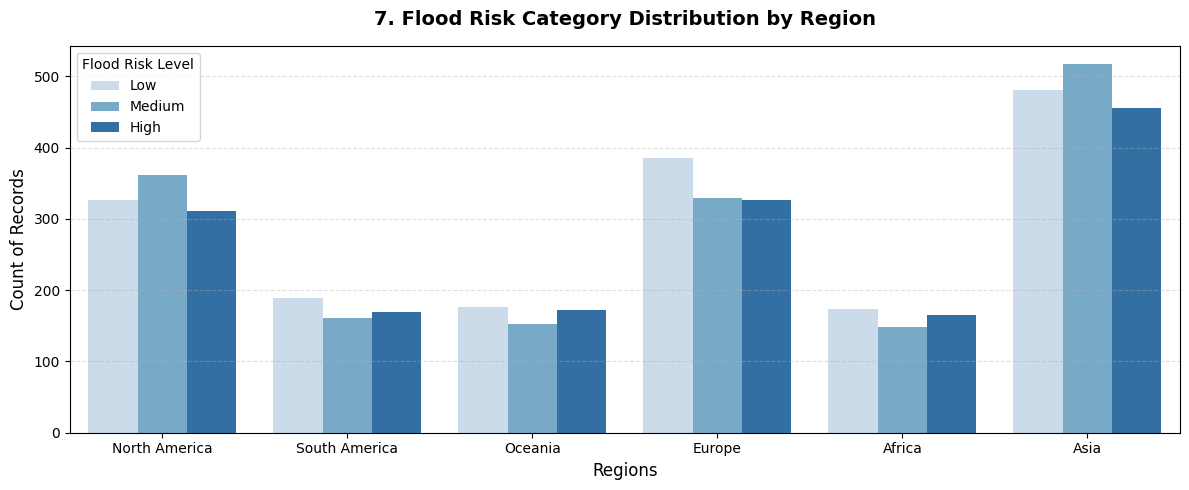

In [23]:
# Which regions face the most critical 'High' flood risk conditions compared to others?
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='region', hue='flood_risk', hue_order=['Low', 'Medium', 'High'], palette='Blues')
plt.title("7. Flood Risk Category Distribution by Region", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Regions", fontsize=12)
plt.ylabel("Count of Records", fontsize=12)
plt.legend(title="Flood Risk Level")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

C:\Users\2025\AppData\Local\Temp\ipykernel_16828\1588019430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='drought_risk', y='rainfall_change_mm', order=['Low', 'Medium', 'High'], palette='Spectral')


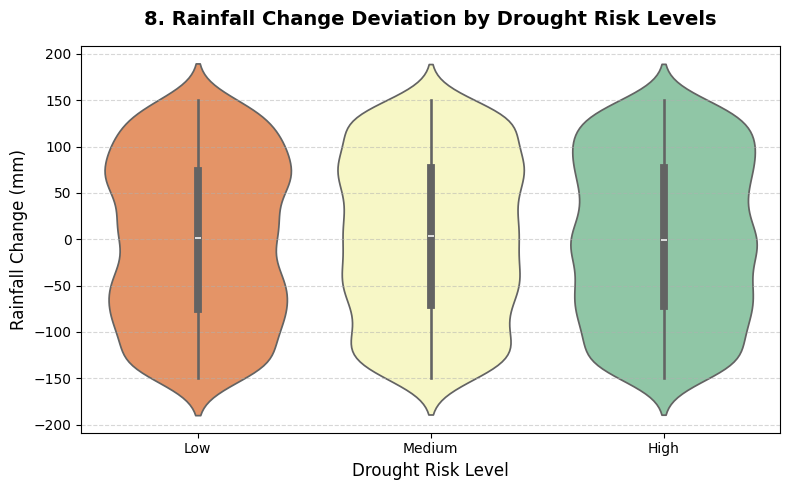

In [22]:
# What is the mathematical relationship between rainfall change (mm) and the categorized drought risk?
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='drought_risk', y='rainfall_change_mm', order=['Low', 'Medium', 'High'], palette='Spectral')
plt.title("8. Rainfall Change Deviation by Drought Risk Levels", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Drought Risk Level", fontsize=12)
plt.ylabel("Rainfall Change (mm)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\2025\AppData\Local\Temp\ipykernel_16828\2506600930.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='sea_level_rise_mm', estimator=np.mean, errorbar=None, palette='magma')


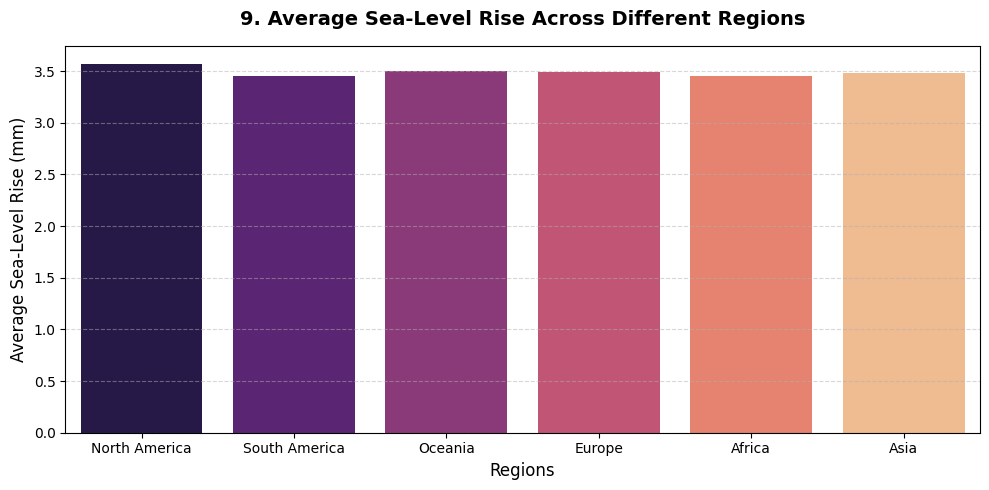

In [21]:
# How does sea-level rise (mm) differ significantly among various global regions?
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='region', y='sea_level_rise_mm', estimator=np.mean, errorbar=None, palette='magma')
plt.title("9. Average Sea-Level Rise Across Different Regions", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Regions", fontsize=12)
plt.ylabel("Average Sea-Level Rise (mm)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

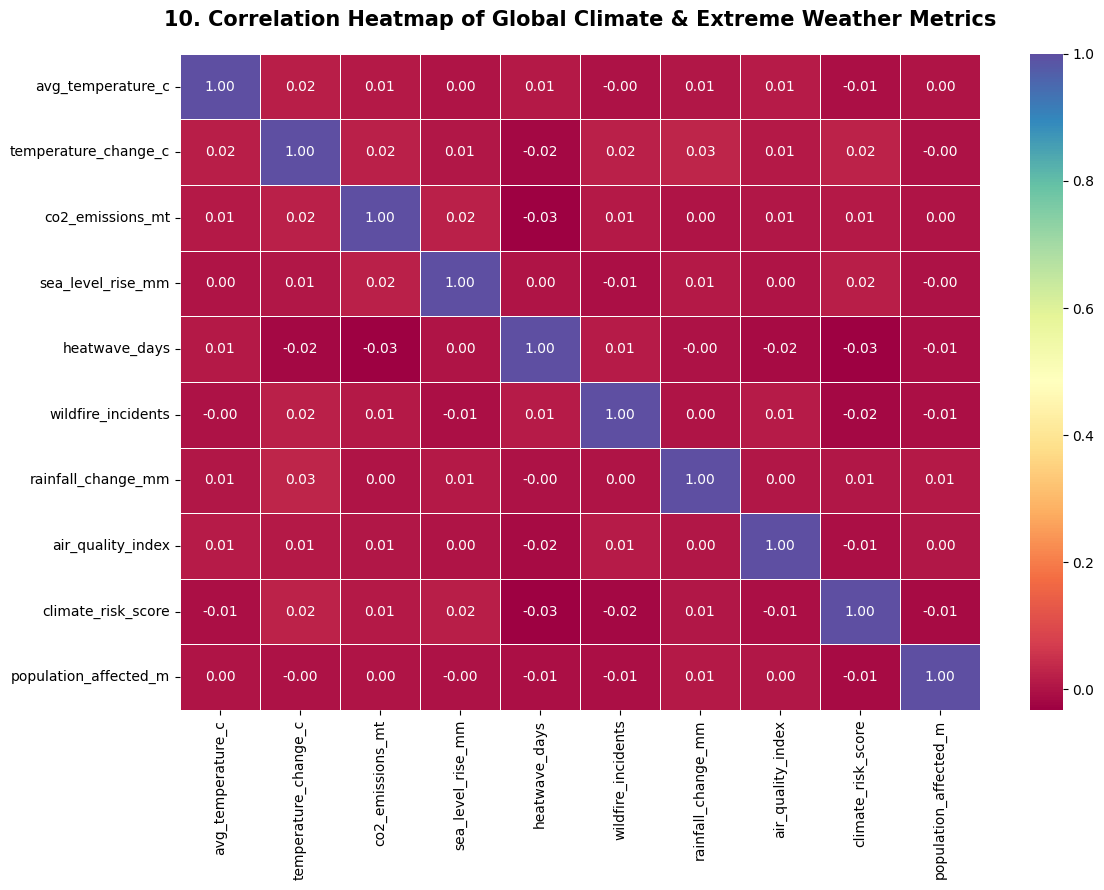

In [20]:
# What is the statistical correlation between a country's average temperature and its final climate risk score?
numeric_cols = ['avg_temperature_c', 'temperature_change_c', 'co2_emissions_mt', 
                'sea_level_rise_mm', 'heatwave_days', 'wildfire_incidents', 
                'rainfall_change_mm', 'air_quality_index', 'climate_risk_score', 'population_affected_m']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap='Spectral', fmt=".2f", linewidths=0.5)
plt.title("10. Correlation Heatmap of Global Climate & Extreme Weather Metrics", fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()